<a href="https://colab.research.google.com/github/tasneemyo/Computer-Vision-Labs/blob/main/Assignment05/DETR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import os
import json
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
import torchvision.transforms as T
from torchvision.ops import box_iou
import tqdm
import random
import warnings
import os
import torch
import torchvision
from torchvision.transforms import functional as F
import numpy as np
from PIL import Image
import json
import time
from typing import Dict, List, Tuple
import zipfile
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output

warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
try:
    from transformers import DetrImageProcessor, DetrForObjectDetection
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
except ImportError:
    print("Installing required packages...")
    os.system('pip install transformers pycocotools')
    from transformers import DetrImageProcessor, DetrForObjectDetection
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval

def setup_coco_dataset():
    """Setup COCO dataset - same as your original function"""
    os.makedirs('coco/images', exist_ok=True)
    os.makedirs('coco/annotations', exist_ok=True)

    # Download validation images
    if not os.path.exists('coco/images/val2017'):
        print("Downloading validation images...")
        os.system('wget http://images.cocodataset.org/zips/val2017.zip -O coco/val2017.zip')
        with zipfile.ZipFile('coco/val2017.zip', 'r') as zip_ref:
            zip_ref.extractall('coco/images')
        os.remove('coco/val2017.zip')

    # Download annotations - FIXED
    if not os.path.exists('coco/annotations/instances_val2017.json'):
        print("Downloading annotations...")
        os.system('wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O coco/annotations.zip')
        with zipfile.ZipFile('coco/annotations.zip', 'r') as zip_ref:
            zip_ref.extractall('coco/temp_annotations')  # Extract to temp directory

        # Find the annotation file recursively
        for root, _, files in os.walk('coco/temp_annotations'):
            if 'instances_val2017.json' in files:
                src = os.path.join(root, 'instances_val2017.json')
                dst = 'coco/annotations/instances_val2017.json'
                os.renames(src, dst)  # This creates directories if needed
                break

        # Cleanup
        os.remove('coco/annotations.zip')
        os.system('rm -rf coco/temp_annotations')  # Remove temp directory

    print("COCO dataset ready!")
    os.system('ls -la coco/annotations/')  # Verify the file exists


In [ ]:

class CocoValidationDatasetForDETR(torch.utils.data.Dataset):
    """Modified version of your COCO dataset class for DETR evaluation"""

    def __init__(self, root, annotation, processor):
        self.root = root
        self.coco = COCO(annotation)
        self.processor = processor
        self.ids = list(sorted(self.coco.imgs.keys()))

        # Load COCO categories properly
        self.coco_categories = self.coco.loadCats(self.coco.getCatIds())
        self.class_id_to_name = {cat['id']: cat['name'] for cat in self.coco_categories}
        self.class_names = [cat['name'] for cat in self.coco_categories]

        # Create mapping for DETR
        self.coco_to_detr_mapping = self._create_category_mapping()

    def _create_category_mapping(self):
        """Create mapping from COCO category IDs to DETR class indices."""
        coco_categories = self.coco.getCatIds()
        mapping = {}
        for i, cat_id in enumerate(sorted(coco_categories)):
            mapping[cat_id] = i
        return mapping

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]

        # Load image (similar to your original approach)
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')

        # Load annotations (similar to your original approach)
        ann_ids = coco.getAnnIds(imgIds=img_id)
        annotations = coco.loadAnns(ann_ids)

        # Convert annotations to target format for evaluation
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in annotations:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])  # Convert to [x1,y1,x2,y2]
            labels.append(ann['category_id'])
            areas.append(ann['area'])
            iscrowd.append(ann['iscrowd'])

        # Prepare target in format compatible with COCO evaluation
        target = {
            'image_id': img_id,
            'annotations': annotations,
            'orig_size': torch.tensor([img_info['height'], img_info['width']]),
            'boxes': torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
            'area': torch.as_tensor(areas, dtype=torch.float32) if areas else torch.zeros((0,), dtype=torch.float32),
            'iscrowd': torch.as_tensor(iscrowd, dtype=torch.int64) if iscrowd else torch.zeros((0,), dtype=torch.int64)
        }

        # Process image for DETR - processor handles resizing automatically
        encoding = self.processor(images=img, return_tensors="pt")
        pixel_values = encoding['pixel_values'].squeeze(0)

        return pixel_values, target

    def __len__(self):
        return len(self.ids)

    def get_class_name(self, class_id):
        #Get class name with proper COCO mapping
        return self.class_id_to_name.get(class_id, f"Unknown class {class_id}")


In [ ]:

class DETREvaluator:

    def __init__(self, model_name: str = "facebook/detr-resnet-50"):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        # Load pretrained DETR model and processor
        self.processor = DetrImageProcessor.from_pretrained(model_name)
        self.model = DetrForObjectDetection.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()

        # COCO class names (91 classes including background)
        self.coco_classes = [
            'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
            'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
            'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
            'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
            'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
            'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
            'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
            'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
            'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
            'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
            'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
            'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
            'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
            'toothbrush'
        ]

    def load_dataset(self, root: str, annotation: str, batch_size: int = 8) -> torch.utils.data.DataLoader:

        dataset = CocoValidationDatasetForDETR(root, annotation, self.processor)
        # Use batch_size=1 to avoid tensor size mismatch, process multiple images in evaluate method
        dataloader = torch.utils.data.DataLoader(
            dataset,
            batch_size=1,  # Process one image at a time to avoid size mismatch
            shuffle=False,
            collate_fn=self._collate_fn,
            num_workers=2 if torch.cuda.is_available() else 0
        )
        return dataloader, batch_size  # Return original batch_size for batch processing

    def _collate_fn(self, batch):
        """Custom collate function for single image batching."""
        pixel_values = batch[0][0]  # Single image
        targets = batch[0][1]       # Single target
        return pixel_values, targets

    def predict_batch(self, pixel_values: torch.Tensor, confidence_threshold: float = 0.8) -> List[Dict]:

        pixel_values = pixel_values.to(self.device)

        with torch.no_grad():
            outputs = self.model(pixel_values)

        # Convert outputs to target sizes and filter by confidence
        predictions = []

        for i in range(len(outputs.logits)):
            # Get predictions for this image
            logits = outputs.logits[i]  # [num_queries, num_classes]
            boxes = outputs.pred_boxes[i]  # [num_queries, 4]

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)[..., :-1]  # remove background class

            # Get confidence scores and predicted classes
            confidence_scores, predicted_classes = probs.max(dim=-1)

            # Filter out background class (class 91) and low confidence predictions
            keep = (predicted_classes != (len(self.coco_classes) - 1)) & (confidence_scores > confidence_threshold)

            filtered_boxes = boxes[keep]
            filtered_scores = confidence_scores[keep]
            filtered_classes = predicted_classes[keep]

            # Convert boxes from [cx, cy, w, h] to [x1, y1, x2, y2] format
            if len(filtered_boxes) > 0:
                # Convert to absolute coordinates (assuming image size normalization)
                boxes_abs = self._box_cxcywh_to_xyxy(filtered_boxes)
            else:
                boxes_abs = torch.empty((0, 4))

            predictions.append({
                'boxes': boxes_abs.cpu(),
                'scores': filtered_scores.cpu(),
                'labels': filtered_classes.cpu()
            })

        return predictions

    def _box_cxcywh_to_xyxy(self, boxes):
        """Convert boxes from [cx, cy, w, h] to [x1, y1, x2, y2] format."""
        cx, cy, w, h = boxes.unbind(-1)
        x1 = cx - 0.5 * w
        y1 = cy - 0.5 * h
        x2 = cx + 0.5 * w
        y2 = cy + 0.5 * h
        return torch.stack([x1, y1, x2, y2], dim=-1)

    def evaluate(self, dataloader_info: tuple, confidence_threshold: float = 0.8) -> Dict:

        if isinstance(dataloader_info, tuple):
            dataloader, batch_size = dataloader_info
        else:
            dataloader = dataloader_info
            batch_size = 1

        print("Starting evaluation...")

        # Prepare for COCO evaluation
        coco_gt = dataloader.dataset.coco
        results = []

        total_images = len(dataloader.dataset)
        start_time = time.time()

        # Process images in batches for efficiency
        batch_images = []
        batch_targets = []
        processed_count = 0

        with torch.no_grad():
            for img_idx, (pixel_values, target) in enumerate(dataloader):
                batch_images.append(pixel_values)
                batch_targets.append(target)

                # Process when batch is full or at the end
                if len(batch_images) == batch_size or img_idx == len(dataloader) - 1:
                    # Stack images for batch processing
                    if len(batch_images) == 1:
                        batch_pixel_values = batch_images[0].unsqueeze(0)
                    else:
                        # Try to stack, if fails process individually
                        try:
                            batch_pixel_values = torch.stack(batch_images)
                        except RuntimeError:
                            # Process individually if sizes don't match
                            for single_img, single_target in zip(batch_images, batch_targets):
                                single_predictions = self.predict_batch(single_img.unsqueeze(0), confidence_threshold)
                                self._process_predictions(single_predictions, [single_target], results)
                            batch_images = []
                            batch_targets = []
                            processed_count += len(batch_images) if batch_images else 1
                            continue

                    # Make predictions on batch
                    predictions = self.predict_batch(batch_pixel_values, confidence_threshold)

                    # Process predictions
                    self._process_predictions(predictions, batch_targets, results)

                    # Clear batch
                    processed_count += len(batch_images)
                    batch_images = []
                    batch_targets = []

                    # Progress update
                    if processed_count % 100 == 0:
                        elapsed = time.time() - start_time
                        print(f"Processed {processed_count}/{total_images} images "
                              f"({elapsed:.1f}s elapsed)")

        print(f"Finished inference. Total detections: {len(results)}")

        # Save results for COCO evaluation
        if len(results) == 0:
            print("No detections found!")
            return {'mAP': 0.0, 'mAP_50': 0.0, 'mAP_75': 0.0}

        # Perform COCO evaluation
        coco_dt = coco_gt.loadRes(results)
        coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()

        # Extract key metrics
        metrics = {
            'mAP': coco_eval.stats[0],           # AP @ IoU=0.50:0.95
            'mAP_50': coco_eval.stats[1],        # AP @ IoU=0.50
            'mAP_75': coco_eval.stats[2],        # AP @ IoU=0.75
            'mAP_small': coco_eval.stats[3],     # AP for small objects
            'mAP_medium': coco_eval.stats[4],    # AP for medium objects
            'mAP_large': coco_eval.stats[5],     # AP for large objects
            'AR_1': coco_eval.stats[6],          # AR @ maxDets=1
            'AR_10': coco_eval.stats[7],         # AR @ maxDets=10
            'AR_100': coco_eval.stats[8],        # AR @ maxDets=100
            'AR_small': coco_eval.stats[9],      # AR for small objects
            'AR_medium': coco_eval.stats[10],    # AR for medium objects
            'AR_large': coco_eval.stats[11],     # AR for large objects
        }

        return metrics

    def _process_predictions(self, predictions: List[Dict], targets: List[Dict], results: List[Dict]):
        """ process predictions and convert to COCO format."""
        for pred, target in zip(predictions, targets):
            img_id = target['image_id']
            orig_h, orig_w = target['orig_size']

            if len(pred['boxes']) > 0:
                # Scale boxes to original image size
                boxes = pred['boxes']
                boxes[:, [0, 2]] *= orig_w  # x coordinates
                boxes[:, [1, 3]] *= orig_h  # y coordinates

                # Convert to COCO format [x, y, w, h]
                boxes_coco = torch.zeros_like(boxes)
                boxes_coco[:, 0] = boxes[:, 0]  # x1
                boxes_coco[:, 1] = boxes[:, 1]  # y1
                boxes_coco[:, 2] = boxes[:, 2] - boxes[:, 0]  # width
                boxes_coco[:, 3] = boxes[:, 3] - boxes[:, 1]  # height

                for box, score, label in zip(boxes_coco, pred['scores'], pred['labels']):
                    # Convert DETR class index back to COCO category ID
                    coco_cat_id = self._detr_to_coco_category(label.item())

                    result = {
                        'image_id': img_id,
                        'category_id': coco_cat_id,
                        'bbox': box.tolist(),
                        'score': score.item()
                    }
                    results.append(result)

    def _detr_to_coco_category(self, detr_class_idx: int) -> int:
        #Convert DETR class index to COCO category ID.
        # This is a simplified mapping - you might need to adjust based on your specific model
        coco_cat_ids = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20,
                       21, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
                       41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58,
                       59, 60, 61, 62, 63, 64, 65, 67, 70, 72, 73, 74, 75, 76, 77, 78, 79,
                       80, 81, 82, 84, 85, 86, 87, 88, 89, 90]

        if detr_class_idx < len(coco_cat_ids):
            return coco_cat_ids[detr_class_idx]
        return 1  # Default to 'person' category


In [ ]:

def main():

    print("Setting up datasets...")
    setup_coco_dataset()

    print("\nVerifying datasets:")
    assert os.path.exists('coco/annotations/instances_val2017.json'), "COCO annotations missing"
    assert os.path.exists('coco/images/val2017'), "COCO images missing"
    print("All datasets verified!")

    # Configuration - using your file structure
    data_dir = 'coco'
    val_annotations = os.path.join(data_dir, 'annotations/instances_val2017.json')
    val_img_dir = os.path.join(data_dir, 'images/val2017')

    MODEL_NAME = "facebook/detr-resnet-50"  # You can also use "facebook/detr-resnet-101"
    BATCH_SIZE = 4  # Adjust based on your GPU memory
    CONFIDENCE_THRESHOLD = 0.8

    # Initialize evaluator
    print(f"\nInitializing DETR model: {MODEL_NAME}")
    evaluator = DETREvaluator(model_name=MODEL_NAME)

    # Load dataset using your approach
    print("Loading COCO validation dataset...")
    dataloader_info = evaluator.load_dataset(val_img_dir, val_annotations, batch_size=BATCH_SIZE)
    if isinstance(dataloader_info, tuple):
        dataloader, actual_batch_size = dataloader_info
        print(f"Dataset loaded: {len(dataloader.dataset)} images")
        print(f"Processing batch size: {actual_batch_size}")
    else:
        dataloader = dataloader_info
        actual_batch_size = BATCH_SIZE
        print(f"Dataset loaded: {len(dataloader.dataset)} images")

    print(f"Number of classes: {len(dataloader.dataset.class_names)}")

    # Display some dataset info (similar to your style)
    print(f"\nDataset information:")
    print(f"- Images directory: {val_img_dir}")
    print(f"- Annotations file: {val_annotations}")
    print(f"- Number of images: {len(dataloader.dataset)}")
    print(f"- Batch size: {actual_batch_size}")

    # Run evaluation
    print(f"\nEvaluating {MODEL_NAME} on COCO validation set...")
    print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")

    start_time = time.time()
    metrics = evaluator.evaluate(dataloader_info, confidence_threshold=CONFIDENCE_THRESHOLD)
    end_time = time.time()

    # Print results
    print("\n" + "="*60)
    print("DETR EVALUATION RESULTS")
    print("="*60)
    print(f"Model: {MODEL_NAME}")
    print(f"Dataset: COCO val2017 ({len(dataloader.dataset)} images)")
    print(f"Evaluation time: {end_time - start_time:.1f} seconds")
    print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
    print()
    print("Average Precision (AP) Metrics:")
    print(f"  mAP @ IoU=0.50:0.95: {metrics['mAP']:.3f}")
    print(f"  mAP @ IoU=0.50:     {metrics['mAP_50']:.3f}")
    print(f"  mAP @ IoU=0.75:     {metrics['mAP_75']:.3f}")
    print(f"  mAP (small):        {metrics['mAP_small']:.3f}")
    print(f"  mAP (medium):       {metrics['mAP_medium']:.3f}")
    print(f"  mAP (large):        {metrics['mAP_large']:.3f}")
    print()
    print("Average Recall (AR) Metrics:")
    print(f"  AR @ maxDets=1:     {metrics['AR_1']:.3f}")
    print(f"  AR @ maxDets=10:    {metrics['AR_10']:.3f}")
    print(f"  AR @ maxDets=100:   {metrics['AR_100']:.3f}")
    print(f"  AR (small):         {metrics['AR_small']:.3f}")
    print(f"  AR (medium):        {metrics['AR_medium']:.3f}")
    print(f"  AR (large):         {metrics['AR_large']:.3f}")

    return metrics, dataloader.dataset


In [ ]:

def visualize_predictions(evaluator, dataset, num_samples=3, confidence_threshold=0.7):
    print(f"\nVisualizing {num_samples} sample predictions...")

    fig, axes = plt.subplots(num_samples, 1, figsize=(15, 5*num_samples))
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        # Get a sample
        pixel_values, target = dataset[i]

        # Make prediction
        predictions = evaluator.predict_batch(pixel_values.unsqueeze(0), confidence_threshold)
        pred = predictions[0]

        # Load original image
        img_id = target['image_id']
        img_info = dataset.coco.loadImgs(img_id)[0]
        img_path = os.path.join(dataset.root, img_info['file_name'])
        img = Image.open(img_path)

        # Plot
        ax = axes[i]
        ax.imshow(img)
        ax.set_title(f"Image ID: {img_id} - {len(pred['boxes'])} detections")

        # Draw predictions
        if len(pred['boxes']) > 0:
            orig_h, orig_w = target['orig_size']
            boxes = pred['boxes']
            boxes[:, [0, 2]] *= orig_w  # x coordinates
            boxes[:, [1, 3]] *= orig_h  # y coordinates

            for box, score, label in zip(boxes, pred['scores'], pred['labels']):
                x1, y1, x2, y2 = box
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                       linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)

                # Get class name
                class_name = dataset.get_class_name(label.item())
                ax.text(x1, y1-5, f"{class_name}: {score:.2f}",
                       color='red', fontsize=8, fontweight='bold')

        ax.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:

# Additional helper function for class-wise analysis
def analyze_per_class_performance(evaluator, dataloader, confidence_threshold=0.7):
    print("\nAnalyzing per-class performance...")

    class_detections = {}
    class_ground_truth = {}

    dataset = dataloader.dataset

    # Count detections and ground truth per class
    with torch.no_grad():
        for batch_idx, (pixel_values, targets) in enumerate(dataloader):
            predictions = evaluator.predict_batch(pixel_values, confidence_threshold)

            for pred, target in zip(predictions, targets):
                # Count predictions
                for label in pred['labels']:
                    class_name = dataset.get_class_name(label.item())
                    class_detections[class_name] = class_detections.get(class_name, 0) + 1

                # Count ground truth
                for label in target['labels']:
                    class_name = dataset.get_class_name(label.item())
                    class_ground_truth[class_name] = class_ground_truth.get(class_name, 0) + 1

            if batch_idx >= 10:  # Limit analysis to first 10 batches for speed
                break

    # Print results
    print("\nClass-wise Detection Analysis (first 10 batches):")
    print(f"{'Class Name':<20} {'Ground Truth':<15} {'Detections':<15} {'Ratio':<10}")
    print("-" * 65)

    all_classes = set(list(class_detections.keys()) + list(class_ground_truth.keys()))
    for class_name in sorted(all_classes):
        gt_count = class_ground_truth.get(class_name, 0)
        det_count = class_detections.get(class_name, 0)
        ratio = det_count / gt_count if gt_count > 0 else 0
        print(f"{class_name:<20} {gt_count:<15} {det_count:<15} {ratio:<10.2f}")


Setting up datasets...
COCO dataset ready!

Verifying datasets:
All datasets verified!

Initializing DETR model: facebook/detr-resnet-50
Using device: cuda


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Loading COCO validation dataset...
loading annotations into memory...
Done (t=0.72s)
creating index...
index created!
Dataset loaded: 5000 images
Processing batch size: 4
Number of classes: 80

Dataset information:
- Images directory: coco/images/val2017
- Annotations file: coco/annotations/instances_val2017.json
- Number of images: 5000
- Batch size: 4

Evaluating facebook/detr-resnet-50 on COCO validation set...
Confidence threshold: 0.8
Starting evaluation...
Finished inference. Total detections: 36921
Loading and preparing results...
DONE (t=0.06s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=11.13s).
Accumulating evaluation results...
DONE (t=2.28s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



Visualizing 3 sample predictions...


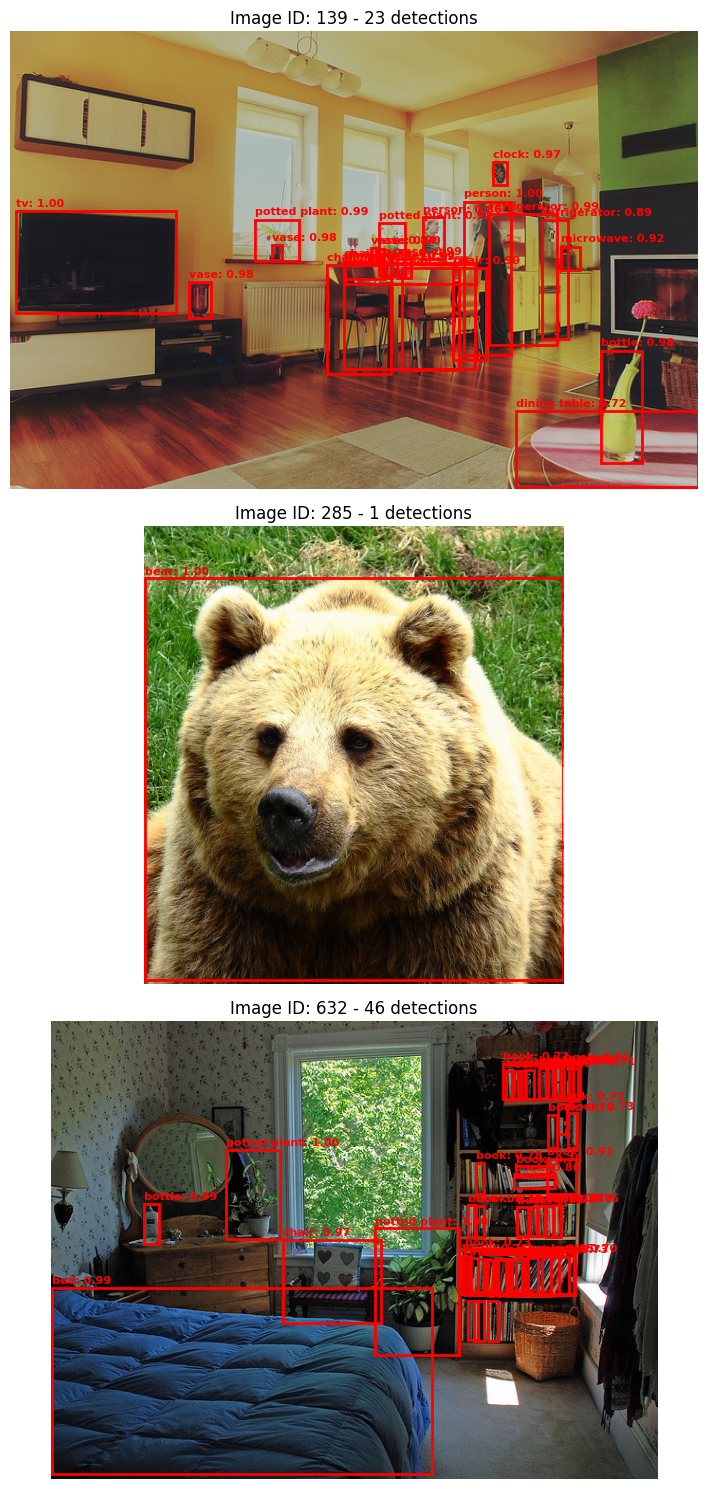

loading annotations into memory...
Done (t=0.56s)
creating index...
index created!

Analyzing per-class performance...
Per-class analysis failed: 'tuple' object has no attribute 'dataset'


In [ ]:

if __name__ == "__main__":
    # Main evaluation
    metrics, dataset = main()

    # Initialize evaluator for additional analysis
    evaluator = DETREvaluator(model_name="facebook/detr-resnet-50")

    # Optional: Visualize some predictions
    try:
        visualize_predictions(evaluator, dataset, num_samples=3)
    except Exception as e:
        print(f"Visualization failed: {e}")

    try:
        val_img_dir = 'coco/images/val2017'
        val_annotations = 'coco/annotations/instances_val2017.json'
        dataloader = evaluator.load_dataset(val_img_dir, val_annotations, batch_size=4)
        analyze_per_class_performance(evaluator, dataloader)
    except Exception as e:
        print(f"Per-class analysis failed: {e}")